In [45]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [46]:
# Load CSV file

df = pd.read_csv(r"C:\Users\aayus\Downloads\pancreatic_cancer_prediction_sample.csv")

# Display first 5 rows
df.head()

,Country,Age,Gender,Smoking_History,Obesity,Diabetes,Chronic_Pancreatitis,Family_History,Hereditary_Condition,Jaundice,...,Stage_at_Diagnosis,Survival_Time_Months,Treatment_Type,Survival_Status,Alcohol_Consumption,Physical_Activity_Level,Diet_Processed_Food,Access_to_Healthcare,Urban_vs_Rural,Economic_Status
0,Canada,64,Female,0,0,0,0,0,0,0,...,Stage III,13,Surgery,0,0,Medium,Low,High,Urban,Low
1,South Africa,77,Male,1,1,0,0,0,0,0,...,Stage III,13,Chemotherapy,0,1,Medium,Medium,Medium,Urban,Low
2,India,71,Female,0,0,0,0,0,0,0,...,Stage IV,3,Chemotherapy,1,0,Medium,High,Low,Rural,Middle
3,Germany,56,Male,0,0,0,0,1,0,1,...,Stage IV,6,Radiation,0,1,Low,Low,Medium,Rural,Middle
4,United States,82,Female,0,0,0,0,1,0,0,...,Stage IV,9,Chemotherapy,1,0,Low,Medium,Medium,Rural,Low


In [47]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Information
df.info()
df.describe()

Dataset Shape: (50000, 24)

Columns:
Index(['Country', 'Age', 'Gender', 'Smoking_History', 'Obesity', 'Diabetes',
       'Chronic_Pancreatitis', 'Family_History', 'Hereditary_Condition',
       'Jaundice', 'Abdominal_Discomfort', 'Back_Pain', 'Weight_Loss',
       'Development_of_Type2_Diabetes', 'Stage_at_Diagnosis',
       'Survival_Time_Months', 'Treatment_Type', 'Survival_Status',
       'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Processed_Food',
       'Access_to_Healthcare', 'Urban_vs_Rural', 'Economic_Status'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Country                        50000 non-null  str  
 1   Age                            50000 non-null  int64
 2   Gender                         50000 non-null  str  
 3   Smoking_History                50000 non-null  int6

,Age,Smoking_History,Obesity,Diabetes,Chronic_Pancreatitis,Family_History,Hereditary_Condition,Jaundice,Abdominal_Discomfort,Back_Pain,Weight_Loss,Development_of_Type2_Diabetes,Survival_Time_Months,Survival_Status,Alcohol_Consumption
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,64.540940,0.299540,0.248260,0.199980,0.099300,0.151680,0.049440,0.199220,0.296500,0.252860,0.349980,0.196220,13.898040,0.128440,0.303460
std,9.973847,0.458061,0.432008,0.399989,0.299067,0.358714,0.216787,0.399418,0.456719,0.434656,0.476968,0.397141,11.272151,0.334582,0.459757
min,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000
50%,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000
75%,71.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,19.000000,0.000000,1.000000
max,90.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,59.000000,1.000000,1.000000


In [48]:
df.isnull().sum()
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

Duplicate rows: 4
After removing duplicates: (49996, 24)


In [49]:
df.columns

Index(['Country', 'Age', 'Gender', 'Smoking_History', 'Obesity', 'Diabetes',
       'Chronic_Pancreatitis', 'Family_History', 'Hereditary_Condition',
       'Jaundice', 'Abdominal_Discomfort', 'Back_Pain', 'Weight_Loss',
       'Development_of_Type2_Diabetes', 'Stage_at_Diagnosis',
       'Survival_Time_Months', 'Treatment_Type', 'Survival_Status',
       'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Processed_Food',
       'Access_to_Healthcare', 'Urban_vs_Rural', 'Economic_Status'],
      dtype='str')

In [50]:
target_column = "Survival_Status"

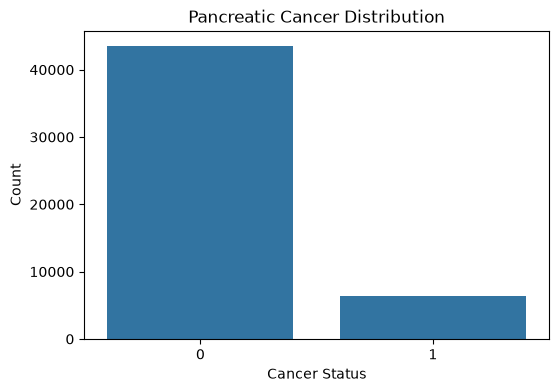

In [51]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df[target_column]
)

plt.title("Pancreatic Cancer Distribution")
plt.xlabel("Cancer Status")
plt.ylabel("Count")
plt.show()

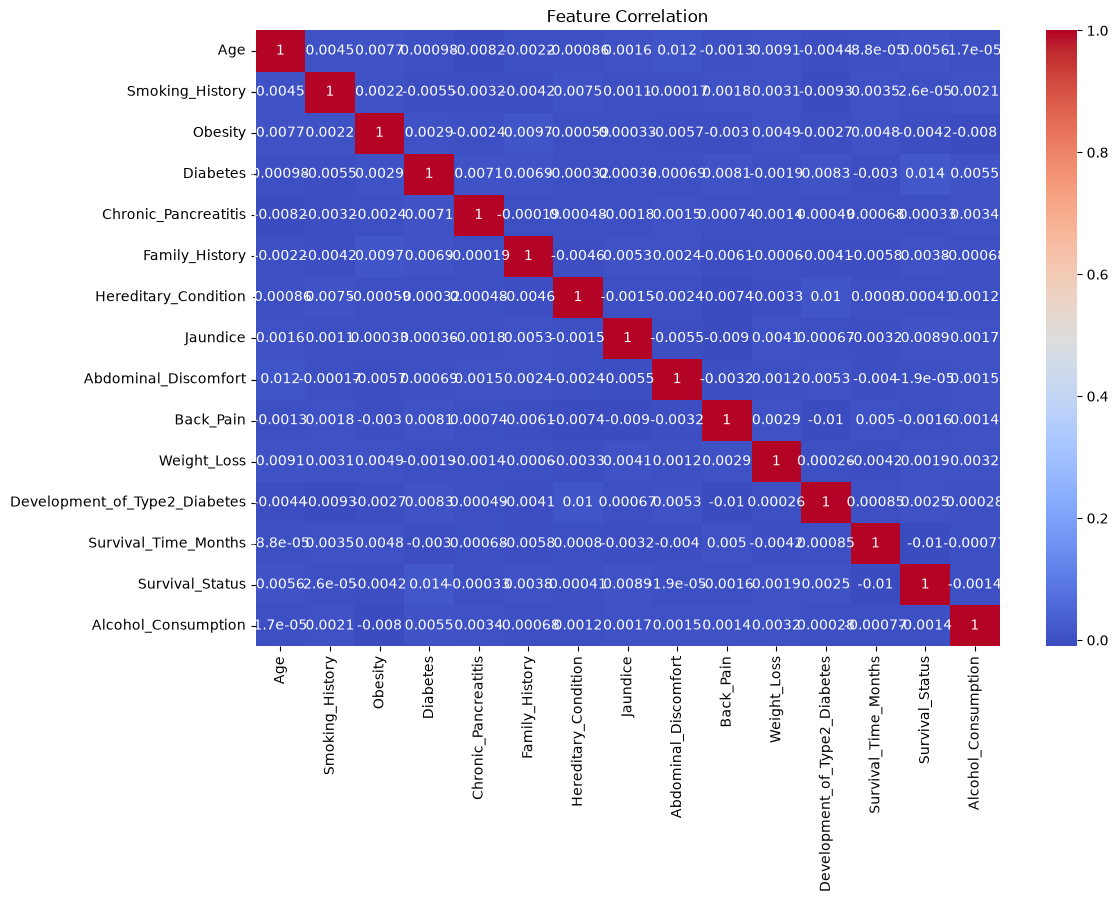

In [52]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

In [53]:
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = encoder.fit_transform(df[column])

df.head()

,Country,Age,Gender,Smoking_History,Obesity,Diabetes,Chronic_Pancreatitis,Family_History,Hereditary_Condition,Jaundice,...,Stage_at_Diagnosis,Survival_Time_Months,Treatment_Type,Survival_Status,Alcohol_Consumption,Physical_Activity_Level,Diet_Processed_Food,Access_to_Healthcare,Urban_vs_Rural,Economic_Status
0,Canada,64,Female,0,0,0,0,0,0,0,...,Stage III,13,Surgery,0,0,Medium,Low,High,Urban,Low
1,South Africa,77,Male,1,1,0,0,0,0,0,...,Stage III,13,Chemotherapy,0,1,Medium,Medium,Medium,Urban,Low
2,India,71,Female,0,0,0,0,0,0,0,...,Stage IV,3,Chemotherapy,1,0,Medium,High,Low,Rural,Middle
3,Germany,56,Male,0,0,0,0,1,0,1,...,Stage IV,6,Radiation,0,1,Low,Low,Medium,Rural,Middle
4,United States,82,Female,0,0,0,0,1,0,0,...,Stage IV,9,Chemotherapy,1,0,Low,Medium,Medium,Rural,Low


In [54]:
X = df.drop(target_column, axis=1)

y = df[target_column]


print("Features:",X.shape)
print("Target:",y.shape)

Features: (49996, 23)
Target: (49996,)


In [55]:

X = df.drop(target_column, axis=1)

y = df[target_column]


print("Features:",X.shape)
print("Target:",y.shape)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


print("Training data:",X_train.shape)
print("Testing data:",X_test.shape)

Training data: (39996, 37)
Testing data: (10000, 37)


In [57]:
models = {

"Logistic Regression":
LogisticRegression(),

"Decision Tree":
DecisionTreeClassifier(),

"Random Forest":
RandomForestClassifier(),

"KNN":
KNeighborsClassifier(),


}

In [58]:
results = []


for name, model in models.items():

    model.fit(X_train,y_train)

    prediction = model.predict(X_test)


    accuracy = accuracy_score(
        y_test,
        prediction
    )

    precision = precision_score(
        y_test,
        prediction,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        prediction,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        prediction,
        average='weighted'
    )


    results.append(
        [
            name,
            accuracy,
            precision,
            recall,
            f1
        ]
    )


results

[['Logistic Regression', 0.8715, 0.75951225, 0.8715, 0.8116615014694096],
 ['Decision Tree', 0.7517, 0.7735241758500007, 0.7517, 0.7622197096671113],
 ['Random Forest', 0.8715, 0.75951225, 0.8715, 0.8116615014694096],
 ['KNN', 0.8602, 0.7776802493414117, 0.8602, 0.8097696337261939]]

In [59]:
result_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)


result_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8715,0.759512,0.8715,0.811662
1,Decision Tree,0.7517,0.773524,0.7517,0.762220
2,Random Forest,0.8715,0.759512,0.8715,0.811662
3,KNN,0.8602,0.777680,0.8602,0.809770


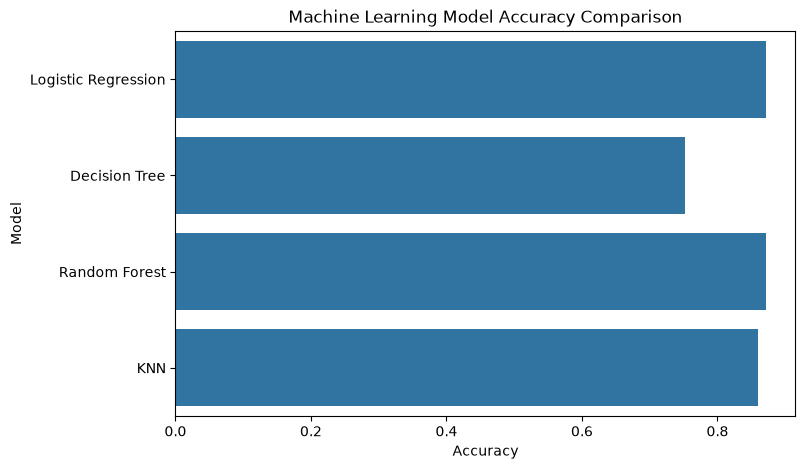

In [60]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=result_df,
    x="Accuracy",
    y="Model"
)

plt.title(
    "Machine Learning Model Accuracy Comparison"
)

plt.show()

In [61]:
best_model_name = result_df.loc[
    result_df["Accuracy"].idxmax(),
    "Model"
]


print(
    "Best Model:",
    best_model_name
)

Best Model: Logistic Regression


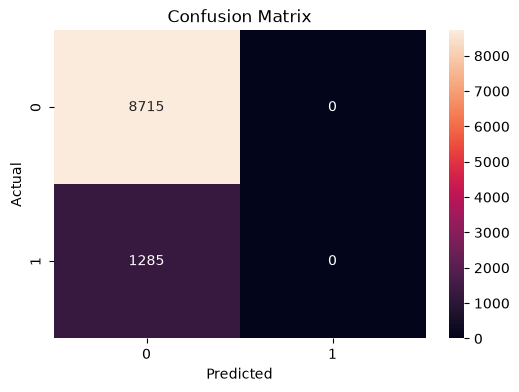

In [62]:
best_model = RandomForestClassifier()

best_model.fit(
    X_train,
    y_train
)


y_pred = best_model.predict(X_test)


cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [63]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      1.00      0.93      8715
           1       0.00      0.00      0.00      1285

    accuracy                           0.87     10000
   macro avg       0.44      0.50      0.47     10000
weighted avg       0.76      0.87      0.81     10000



In [66]:
import pickle


pickle.dump(
    best_model,
    open(
        "pancreatic_cancer_model.pkl",
        "wb"
    )
)


print("Model Saved Successfully")

Model Saved Successfully
